In [1]:
!pip install ultralytics

import ultralytics
ultralytics.checks()

Ultralytics 8.4.77 🚀 Python-3.9.6 torch-2.8.0 CPU (Apple M2)
Setup complete ✅ (10 CPUs, 16.0 GB RAM, 202.6/228.3 GB disk)


In [2]:
import os
from pathlib import Path


DATASET_DIR = Path('/Users/irodaibrohimova/Downloads/YOLO.yolov11')
DATA_YAML = DATASET_DIR / 'data.yaml'

assert DATA_YAML.exists(), f'data.yaml not found at {DATA_YAML}'
print('Dataset root:', DATASET_DIR)

for split in ['train', 'valid', 'test']:
    img_dir = DATASET_DIR / split / 'images'
    lbl_dir = DATASET_DIR / split / 'labels'
    imgs = list(img_dir.glob('*')) if img_dir.exists() else []
    lbls = list(lbl_dir.glob('*')) if lbl_dir.exists() else []
    print(f'  {split:6s}  images: {len(imgs):4d}  labels: {len(lbls):4d}')

Dataset root: /Users/irodaibrohimova/Downloads/YOLO.yolov11
  train   images:   59  labels:   59
  valid   images:   17  labels:   17
  test    images:    8  labels:    8


In [3]:
import yaml

with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

print('Classes:', cfg.get('names'))
print('nc     :', cfg.get('nc'))

# Fix typo if still present
names = cfg.get('names', [])
fixed = ['capacitor' if n == 'capasitor' else n for n in names]
if fixed != names:
    print('Fixing typo: capasitor -> capacitor')
    cfg['names'] = fixed
    with open(DATA_YAML, 'w') as f:
        yaml.dump(cfg, f)
    print('data.yaml updated.')
else:
    print('Class names are clean.')

Classes: ['board', 'capacitor', 'chip', 'knob']
nc     : 4
Class names are clean.


In [8]:
from pathlib import Path

DATASET_DIR = Path('/Users/irodaibrohimova/Downloads/YOLO.yolov11')  

def convert_box_to_polygon(parts):
    # YOLO box format: class cx cy w h
    cls = parts[0]
    cx, cy, w, h = map(float, parts[1:5])
    x1 = cx - w/2;  y1 = cy - h/2
    x2 = cx + w/2;  y2 = cy - h/2
    x3 = cx + w/2;  y3 = cy + h/2
    x4 = cx - w/2;  y4 = cy + h/2
    return f'{cls} {x1:.6f} {y1:.6f} {x2:.6f} {y2:.6f} {x3:.6f} {y3:.6f} {x4:.6f} {y4:.6f}'

converted_files = 0
converted_lines = 0

for split in ['train', 'valid', 'test']:
    lbl_dir = DATASET_DIR / split / 'labels'
    for lbl_file in lbl_dir.glob('*.txt'):
        lines = lbl_file.read_text().strip().split('\n')
        new_lines = []
        changed = False
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:  # bounding box: cls cx cy w h
                new_lines.append(convert_box_to_polygon(parts))
                changed = True
                converted_lines += 1
            else:
                new_lines.append(line)  # already a polygon, leave it
        if changed:
            lbl_file.write_text('\n'.join(new_lines))
            converted_files += 1

print(f'Done. Converted {converted_lines} boxes across {converted_files} label files.')

Done. Converted 328 boxes across 52 label files.


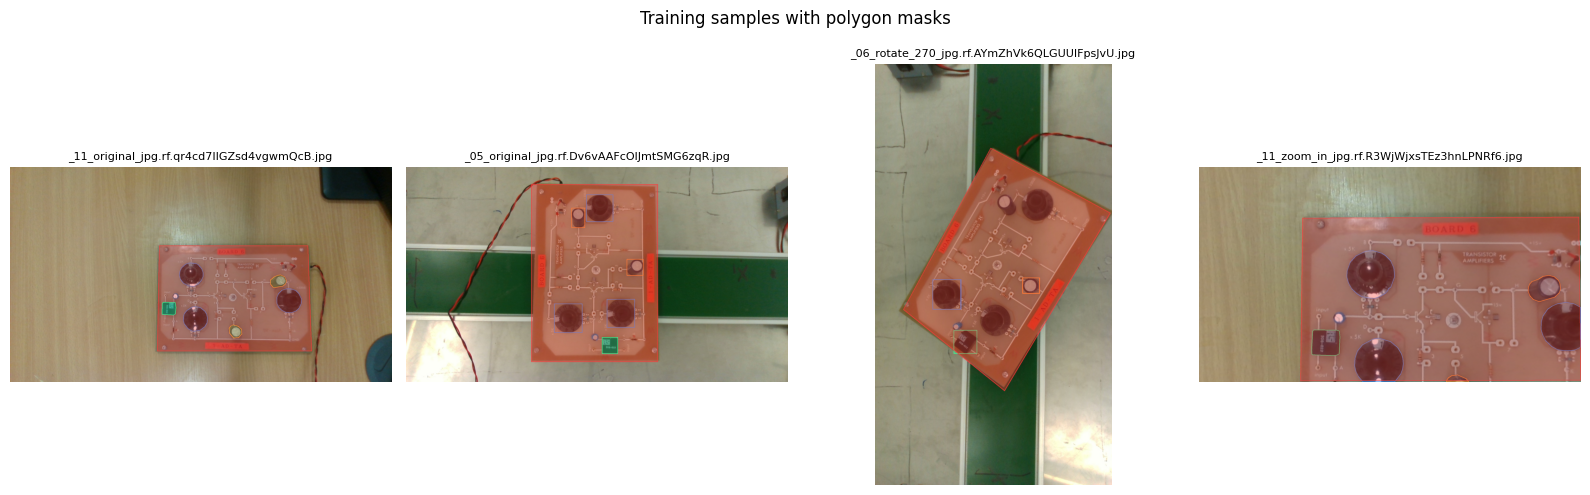

In [9]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

COLORS = [
    (255,  56,  56),  # board
    (255, 157,  56),  # capacitor
    ( 56, 255, 157),  # chip
    ( 56, 157, 255),  # knob
    (157,  56, 255),  # null
]

img_dir = DATASET_DIR / 'train' / 'images'
lbl_dir = DATASET_DIR / 'train' / 'labels'
img_paths = sorted(img_dir.glob('*.jpg')) + sorted(img_dir.glob('*.png'))
samples = random.sample(img_paths, min(4, len(img_paths)))

fig, axes = plt.subplots(1, len(samples), figsize=(16, 5))
if len(samples) == 1:
    axes = [axes]

for ax, img_path in zip(axes, samples):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    overlay = img.copy()

    lbl_path = lbl_dir / (img_path.stem + '.txt')
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                cls = int(parts[0])
                coords = list(map(float, parts[1:]))
                pts = np.array(coords).reshape(-1, 2)
                pts[:, 0] *= w
                pts[:, 1] *= h
                pts = pts.astype(np.int32)
                color = COLORS[cls % len(COLORS)]
                cv2.fillPoly(overlay, [pts], color)
                cv2.polylines(img, [pts], True, color, 2)

    blended = cv2.addWeighted(overlay, 0.35, img, 0.65, 0)
    ax.imshow(blended)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')

plt.suptitle('Training samples with polygon masks')
plt.tight_layout()
plt.show()

In [10]:
from ultralytics import YOLO

# Configuration
MODEL_SIZE = 'n'       # n=nano (best for 84 images), s=small, m=medium
EPOCHS     = 100
IMG_SIZE   = 640
BATCH_SIZE = 8         # reduce to 4 if you get out-of-memory errors
PROJECT    = 'ewaste_seg'
RUN_NAME   = 'yolo11_run1'

model = YOLO(f'yolo11{MODEL_SIZE}-seg.pt')  # downloads pretrained weights

results = model.train(
    data     = str(DATA_YAML),
    epochs   = EPOCHS,
    imgsz    = IMG_SIZE,
    batch    = BATCH_SIZE,
    project  = PROJECT,
    name     = RUN_NAME,
    patience = 20,       # early stopping
    save     = True,
    plots    = True,
    degrees  = 15,
    flipud   = 0.3,
    fliplr   = 0.5,
    mosaic   = 1.0,
    mixup    = 0.1,
)
print('Best weights:', results.save_dir)

New https://pypi.org/project/ultralytics/8.4.78 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.77 🚀 Python-3.9.6 torch-2.8.0 CPU (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/irodaibrohimova/Downloads/YOLO.yolov11/data.yaml, degrees=15, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11n-seg.pt, momentum=0.937, 

/Users/irodaibrohimova/Library/Python/3.9/lib/python/site-packages/ultralytics/data/augment.py:1290: RuntimeWarning: divide by zero encountered in matmul
  xy = xy @ M.T  # transform
/Users/irodaibrohimova/Library/Python/3.9/lib/python/site-packages/ultralytics/data/augment.py:1290: RuntimeWarning: overflow encountered in matmul
  xy = xy @ M.T  # transform
/Users/irodaibrohimova/Library/Python/3.9/lib/python/site-packages/ultralytics/data/augment.py:1290: RuntimeWarning: invalid value encountered in matmul
  xy = xy @ M.T  # transform


      1/100         0G      1.082      2.476      3.655      1.052          0         43        640: 100% ━━━━━━━━━━━━ 8/8 1.6s/it 13.2s1.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.4s/it 2.7s8.9s
                   all         17        108    0.00323      0.266      0.114     0.0885    0.00335      0.257      0.109     0.0734

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size


/Users/irodaibrohimova/Library/Python/3.9/lib/python/site-packages/ultralytics/data/augment.py:1290: RuntimeWarning: divide by zero encountered in matmul
  xy = xy @ M.T  # transform
/Users/irodaibrohimova/Library/Python/3.9/lib/python/site-packages/ultralytics/data/augment.py:1290: RuntimeWarning: overflow encountered in matmul
  xy = xy @ M.T  # transform
/Users/irodaibrohimova/Library/Python/3.9/lib/python/site-packages/ultralytics/data/augment.py:1290: RuntimeWarning: invalid value encountered in matmul
  xy = xy @ M.T  # transform


      2/100         0G     0.9091      1.829      3.313      0.951          0         40        640: 100% ━━━━━━━━━━━━ 8/8 1.5s/it 11.7s1.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.4s/it 2.7s9.0s
                   all         17        108    0.00381      0.261      0.211      0.183    0.00443      0.252      0.193      0.159

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size


...

     96/100         0G     0.5279     0.9003     0.5712     0.8281          0         20        640: 100% ━━━━━━━━━━━━ 8/8 1.4s/it 10.8s1.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.6s/it 3.2s<10.5s
                   all         17        108      0.981      0.979      0.993      0.882      0.994      0.943      0.963      0.645

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size


/Users/irodaibrohimova/Library/Python/3.9/lib/python/site-packages/ultralytics/data/augment.py:1290: RuntimeWarning: divide by zero encountered in matmul
  xy = xy @ M.T  # transform
/Users/irodaibrohimova/Library/Python/3.9/lib/python/site-packages/ultralytics/data/augment.py:1290: RuntimeWarning: overflow encountered in matmul
  xy = xy @ M.T  # transform
/Users/irodaibrohimova/Library/Python/3.9/lib/python/site-packages/ultralytics/data/augment.py:1290: RuntimeWarning: invalid value encountered in matmul
  xy = xy @ M.T  # transform


     97/100         0G      0.476     0.8935     0.5572     0.8373          0         21        640: 100% ━━━━━━━━━━━━ 8/8 1.4s/it 11.2s1.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.6s/it 3.2s<10.6s
                   all         17        108       0.98      0.978      0.993      0.884      0.993      0.943      0.963      0.644

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size


/Users/irodaibrohimova/Library/Python/3.9/lib/python/site-packages/ultralytics/data/augment.py:1290: RuntimeWarning: divide by zero encountered in matmul
  xy = xy @ M.T  # transform
/Users/irodaibrohimova/Library/Python/3.9/lib/python/site-packages/ultralytics/data/augment.py:1290: RuntimeWarning: overflow encountered in matmul
  xy = xy @ M.T  # transform
/Users/irodaibrohimova/Library/Python/3.9/lib/python/site-packages/ultralytics/data/augment.py:1290: RuntimeWarning: invalid value encountered in matmul
  xy = xy @ M.T  # transform


     98/100         0G     0.5004     0.8409     0.5659     0.8297          0         21        640: 100% ━━━━━━━━━━━━ 8/8 1.4s/it 10.8s1.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.6s/it 3.2s<10.6s
                   all         17        108       0.98      0.978      0.993      0.885      0.992      0.943      0.963      0.645
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 78, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

98 epochs completed in 0.408 hours.
Optimizer stripped from /opt/homebrew/runs/segment/ewaste_seg/yolo11_run1-2/weights/last.pt, 6.0MB
Optimizer stripped from /opt/homebrew/runs/segment/ewaste_seg/yolo11_run1-2/weights/best.pt, 6.0MB

Validating /opt/homebrew/runs/segment

In [12]:
from pathlib import Path

best_weights = Path('/opt/homebrew/runs/segment/ewaste_seg/yolo11_run1-2/weights/best.pt')
model_eval = YOLO(str(best_weights))

metrics = model_eval.val(data=str(DATA_YAML), imgsz=IMG_SIZE)
print(f'Mask mAP50    : {metrics.seg.map50:.4f}')
print(f'Mask mAP50-95 : {metrics.seg.map:.4f}')
print(f'Box  mAP50    : {metrics.box.map50:.4f}')

Ultralytics 8.4.77 🚀 Python-3.9.6 torch-2.8.0 CPU (Apple M2)
YOLO11n-seg summary (fused): 114 layers, 2,835,348 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6082.0±1326.2 MB/s, size: 272.0 KB)
val: Scanning /Users/irodaibrohimova/Downloads/YOLO.yolov11/valid/labels.cache... 17 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 17/17 5.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.3s/it 2.6s8.4s
                   all         17        108      0.984      0.976      0.992      0.879      0.985      0.976      0.987      0.675
                 board         17         17       0.96          1      0.995      0.893      0.961          1      0.995      0.885
             capacitor         17         32          1      0.951      0.983      0.849          1      0.951      0.983      0.521
                  chip         13    

Found 8 result images in /opt/homebrew/runs/segment/ewaste_seg/test_inference-2


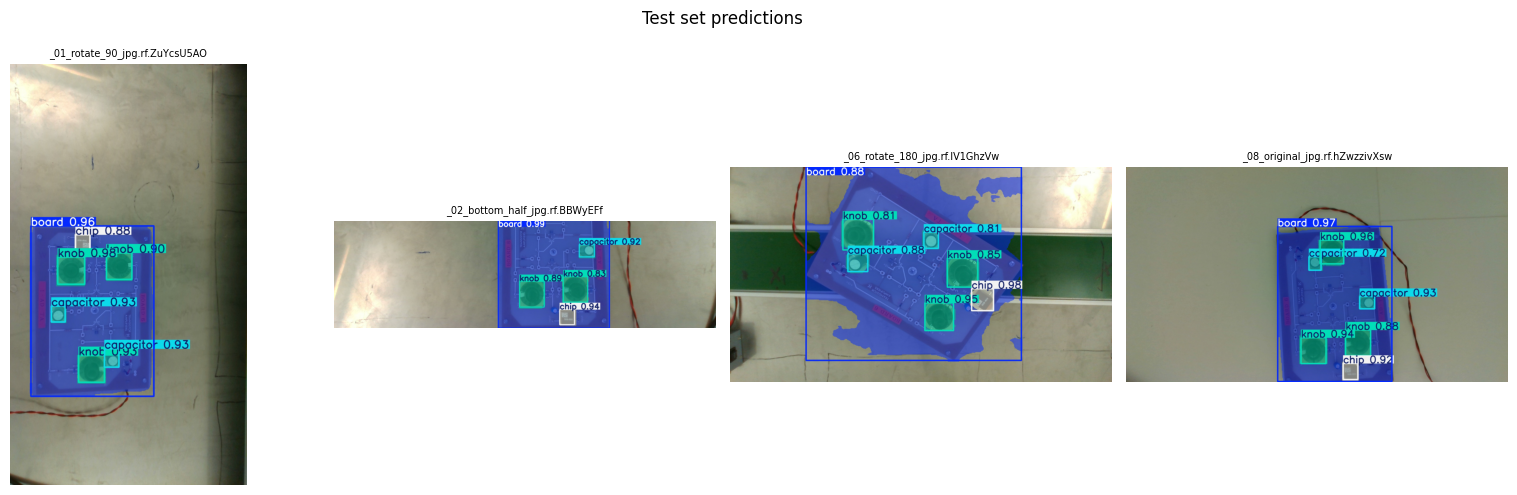

In [15]:
# Fixed path — use where YOLO actually saved the results
result_dir  = Path('/opt/homebrew/runs/segment/ewaste_seg/test_inference-2')
result_imgs = sorted(result_dir.glob('*.jpg'))

print(f'Found {len(result_imgs)} result images in {result_dir}')

fig, axes = plt.subplots(1, min(4, len(result_imgs)), figsize=(16, 5))
if len(result_imgs) == 1:
    axes = [axes]

for ax, rp in zip(axes, result_imgs[:4]):
    img = cv2.cvtColor(cv2.imread(str(rp)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(rp.name[:30], fontsize=7)

plt.suptitle('Test set predictions', fontsize=12)
plt.tight_layout()
plt.show()